# WAR vs. Contract Value: An Exploratory Path Toward a Deterministic Formula

This notebook walks through an exploratory data-analysis exercise on `dataset/contracts_with_stats.csv`,
looking specifically at contracts signed for the **2026 season** (i.e. the 2025-26 offseason for free
agents). The starting question was simple — *how well does WAR (1yr/3yr/5yr) correlate with contract
value?* — and each section below builds on the last, the same way the investigation actually unfolded:
correlation -> multiple regression with more features -> testing whether those regressions are actually
*accurate* -> testing whether they're at least useful for *relative* ranking, even where they're not
accurate enough to use as point predictions.

**This is exploratory analysis, not part of the production pipeline** (`data_generation/`, `agent/`).
Nothing here is wired into `make dataset`/`make predict`/etc. — it's a standalone research notebook.

**Headline finding:** simple 2-3 feature linear formulas explain real, substantial variance in contract
value (R² up to ~0.75 for arbitration), but their *point-estimate* accuracy (typical error of 25-40% of
AAV) isn't tight enough to replace the project's LLM-agent-based prediction approach. They're more useful
as a **relative-value / percentile-ranking signal** (91% land within one quartile-tier of a player's true
value) than as a standalone dollar predictor — see the final sections.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import rankdata

pd.set_option("display.max_columns", None)
plt.rcParams["figure.dpi"] = 110

DATASET_DIR = "../dataset"


## 1. Load and prepare the data

`contracts_with_stats.csv` is the wide-format, per-contract dataset joined with prior-season performance
stats across four rolling windows (1/3/5/10-year). We filter to `contract_year == 2026` and derive AAV
(average annual value = total value / duration).

One data wrinkle worth calling out immediately: `bat_war_*` columns are populated (as ~0, from token
plate appearances) even for pure pitchers, and vice versa for `pit_war_*` on position players. Naively
taking "whichever WAR column is non-null" silently prefers a pitcher's near-zero *batting* WAR over their
real *pitching* WAR. We classify batter vs. pitcher from the `position` column instead, and use that to
pick the right WAR family throughout this notebook.


In [2]:
df = pd.read_csv(f"{DATASET_DIR}/contracts_with_stats.csv")
players = pd.read_csv(f"{DATASET_DIR}/players.csv").drop_duplicates(subset="player_id")

d26 = df[df["contract_year"] == 2026].copy()
d26["aav"] = d26["value"] / d26["duration"]
d26["log_aav"] = np.log(d26["aav"])

pos = d26["position"]
is_pitcher = pos.str.contains("SP|RP", regex=True) | (pos == "P")
is_sp = pos.str.contains("SP", regex=True)
is_rp = pos.str.contains("RP", regex=True) & ~is_sp
d26["role"] = np.select([is_sp, is_rp, is_pitcher], ["SP", "RP", "P(other)"], default="batter")

for w in ("1y", "3y", "5y"):
    d26[f"war_{w}"] = np.where(is_pitcher, d26[f"pit_war_{w}"], d26[f"bat_war_{w}"])
    d26[f"volume_{w}"] = np.where(
        is_pitcher, d26[f"pit_innings_pitched_{w}"], d26[f"bat_plate_appearances_{w}"]
    )

print(f"2026 contracts: {len(d26)}")
d26["contract_type"].value_counts()


2026 contracts: 770


contract_type
pre-arb       396
arb           211
free-agent    163
Name: count, dtype: int64

## 2. WAR vs. AAV: simple correlation, by contract phase

Pre-arb, arbitration, and free agency are fundamentally different pay processes, so we look at each
phase separately rather than pooling everything together.


In [3]:
windows = ["war_1y", "war_3y", "war_5y"]
rows = []
for phase in ["pre-arb", "arb", "free-agent"]:
    sub = d26[d26["contract_type"] == phase]
    for w in windows:
        pair = sub[[w, "aav"]].dropna()
        if len(pair) < 5:
            continue
        rows.append({
            "phase": phase,
            "window": w,
            "n": len(pair),
            "pearson_r": pair[w].corr(pair["aav"], method="pearson"),
            "spearman_rho": pair[w].corr(pair["aav"], method="spearman"),
        })
corr_table = pd.DataFrame(rows)
corr_table


,phase,window,n,pearson_r,spearman_rho
0,pre-arb,war_1y,369,0.283165,0.479505
1,pre-arb,war_3y,129,0.225196,0.380271
2,pre-arb,war_5y,6,-0.575527,-0.811679
3,arb,war_1y,202,0.685769,0.626176
4,arb,war_3y,188,0.701268,0.755626
5,arb,war_5y,108,0.801230,0.763938
6,free-agent,war_1y,147,0.789409,0.753553
7,free-agent,war_3y,138,0.815800,0.757230
8,free-agent,war_5y,118,0.759632,0.658456


**Reading this table:**
- **Pre-arb is essentially uncorrelated** with performance (weak, noisy r) — expected, since pre-arb pay
  clusters tightly at the CBA league minimum regardless of how well a player performs.
- **Arbitration correlates well and gets *stronger* with longer windows** (r rises from 1yr to 5yr) —
  consistent with arbitration rewarding a cumulative track record, not just the walk year.
- **Free agency correlates strongly at every window**, typically peaking around the 3yr window — recent
  performance dominates, but not to the exclusion of a longer résumé.

### Pearson vs. Spearman

**Pearson r** measures *linear* correlation: proportional change, sensitive to outliers and to whether
the true relationship is actually a straight line. **Spearman rho** first converts both variables to
ranks, then correlates the ranks — it only asks "does Y tend to go up whenever X goes up," regardless of
the functional shape, and is far more robust to outliers.

Where Spearman is noticeably higher than Pearson in the table above (arbitration, mostly), that's a sign
the true relationship is monotonic but not linear — contract dollars are strongly right-skewed, so a log
transform (`log_aav`, already computed above) tends to fit better than the raw-dollar version.


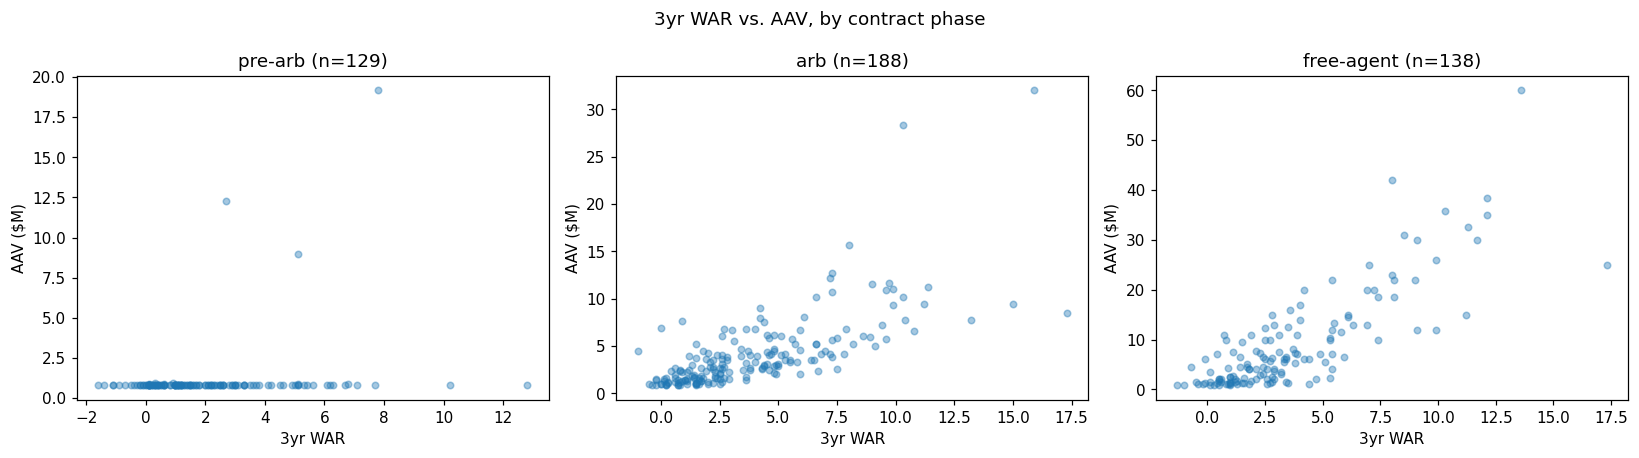

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=False)
for ax, phase in zip(axes, ["pre-arb", "arb", "free-agent"]):
    sub = d26[d26["contract_type"] == phase]
    pair = sub[["war_3y", "aav"]].dropna()
    ax.scatter(pair["war_3y"], pair["aav"], alpha=0.4, s=18)
    ax.set_title(f"{phase} (n={len(pair)})")
    ax.set_xlabel("3yr WAR")
    ax.set_ylabel("AAV ($M)")
fig.suptitle("3yr WAR vs. AAV, by contract phase")
fig.tight_layout()


## 3. Multiple regression: adding features arb and free agency actually depend on

A single-variable correlation can't separate WAR's effect from a *confounding* variable that also drives
pay. For arbitration, that's **service time** (it literally determines which arb-year/pay-scale a player
is in). For free agency, that's **age**. We fit standardized OLS (all variables z-scored, so coefficients
are directly comparable effect sizes and are *partial* — each controls for the other) by hand with
`numpy.linalg.lstsq`, since this environment doesn't have `statsmodels` installed.


In [5]:
def standardized_ols(data, y_col, x_cols):
    """OLS on z-scored columns -- coefficients are partial correlations / effect sizes."""
    sub = data[[y_col] + x_cols].dropna()
    n = len(sub)
    z = (sub - sub.mean()) / sub.std()
    X = np.column_stack([z[c].values for c in x_cols] + [np.ones(n)])
    y = z[y_col].values
    coefs, *_ = np.linalg.lstsq(X, y, rcond=None)
    y_hat = X @ coefs
    ss_res = ((y - y_hat) ** 2).sum()
    ss_tot = ((y - y.mean()) ** 2).sum()
    r2 = 1 - ss_res / ss_tot
    return n, dict(zip(x_cols, coefs)), r2


def raw_ols(data, y_col, x_cols):
    """Same fit, but in original units -- gives an interpretable 'AAV = ... ' equation."""
    sub = data[[y_col] + x_cols].dropna()
    n = len(sub)
    X = np.column_stack([sub[c].values for c in x_cols] + [np.ones(n)])
    y = sub[y_col].values
    coefs, *_ = np.linalg.lstsq(X, y, rcond=None)
    y_hat = X @ coefs
    resid = y - y_hat
    ss_res = (resid ** 2).sum()
    ss_tot = ((y - y.mean()) ** 2).sum()
    r2 = 1 - ss_res / ss_tot
    return n, coefs, r2, resid


In [6]:
arb = d26[d26["contract_type"] == "arb"]

print("Arbitration: AAV ~ WAR + service_time (standardized/partial coefficients)\n")
for w in ("war_1y", "war_3y", "war_5y"):
    n, coefs, r2 = standardized_ols(arb, "aav", [w, "service_time"])
    print(f"  {w:8s} + service_time: n={n:3d}  {w}={coefs[w]:+.3f}  service_time={coefs['service_time']:+.3f}  R^2={r2:.3f}")


Arbitration: AAV ~ WAR + service_time (standardized/partial coefficients)

  war_1y   + service_time: n=196  war_1y=+0.579  service_time=+0.355  R^2=0.544
  war_3y   + service_time: n=183  war_3y=+0.651  service_time=+0.378  R^2=0.636
  war_5y   + service_time: n=106  war_5y=+0.720  service_time=+0.212  R^2=0.664


WAR's partial coefficient barely moves once service_time is controlled for — so WAR isn't mostly a proxy
for "more service time to accumulate value," it carries real independent signal. service_time also has a
genuine independent effect, confirming what the project's prediction-agent prompt already assumes: the
arb-year bucket itself shifts pay beyond what performance alone predicts.

The best-fitting single window (5yr) as a real equation:


In [7]:
n, coefs, r2, resid = raw_ols(arb, "aav", ["war_5y", "service_time"])
print(f"n={n}   R^2={r2:.3f}")
print(f"AAV = {coefs[0]:.3f} * war_5y + {coefs[1]:.3f} * service_time + {coefs[2]:.3f}")
print()
print("Service time in this data ranges from "
      f"{arb['service_time'].min():.2f} to {arb['service_time'].max():.2f} years.")
print(f"=> crossing the full arb-1 to arb-3 range (~3 years) adds roughly "
      f"${coefs[1]*3:.1f}M in AAV from the bucket alone, holding WAR fixed.")


n=106   R^2=0.664
AAV = 0.701 * war_5y + 1.065 * service_time + -3.355

Service time in this data ranges from 2.14 to 5.17 years.
=> crossing the full arb-1 to arb-3 range (~3 years) adds roughly $3.2M in AAV from the bucket alone, holding WAR fixed.


In [8]:
fa = d26[d26["contract_type"] == "free-agent"]

print("Free agency: AAV ~ WAR + age (standardized/partial coefficients)\n")
for w in ("war_1y", "war_3y", "war_5y"):
    n, coefs, r2 = standardized_ols(fa, "aav", [w, "age"])
    print(f"  {w:8s} + age: n={n:3d}  {w}={coefs[w]:+.3f}  age={coefs['age']:+.3f}  R^2={r2:.3f}")


Free agency: AAV ~ WAR + age (standardized/partial coefficients)

  war_1y   + age: n= 97  war_1y=+0.784  age=-0.212  R^2=0.705
  war_3y   + age: n= 93  war_3y=+0.781  age=-0.185  R^2=0.692
  war_5y   + age: n= 87  war_5y=+0.727  age=-0.201  R^2=0.628


Unlike arbitration, **1yr WAR** is the best-fitting single window for free agency — recent performance carries the most weight when the market is setting a price. Raw equation:

In [9]:
n, coefs, r2, resid = raw_ols(fa, "aav", ["war_1y", "age"])
print(f"n={n}   R^2={r2:.3f}")
print(f"AAV = {coefs[0]:.3f} * war_1y + ({coefs[1]:.3f}) * age + {coefs[2]:.3f}")
print()
print(f"=> each extra year of age is associated with about ${-coefs[1]:.2f}M LESS AAV, holding 1yr WAR fixed.")
print(f"=> each extra win of 1yr WAR is worth about ${coefs[0]:.2f}M in AAV, holding age fixed.")
FA_FORMULA_COEFS = coefs  # reused in section 7 for the top-10 ranking


n=97   R^2=0.705
AAV = 6.058 * war_1y + (-0.828) * age + 29.727

=> each extra year of age is associated with about $0.83M LESS AAV, holding 1yr WAR fixed.
=> each extra win of 1yr WAR is worth about $6.06M in AAV, holding age fixed.


**Interpretation:** age is a real, negative, independent driver of free-agent value, but it's clearly
secondary to performance — roughly 1.4 years of age-related decline is offset by a single additional win
of 1yr WAR. That matches the qualitative guidance already encoded in the prediction agent's prompt
(`agent/predict/prompts.py`): *"age cuts against value... but performance trajectory dominates age."*

*Caveat:* this is a linear fit over a fairly narrow age band (~27-40) with under 100 rows — it can't
capture a possible acceleration/"cliff" effect past age ~36-37. A bucketed age analysis or an age² term
would be needed to check for that.


## 4. Does normalizing WAR by playing time help? (WAR per PA / per IP)

A natural next question: is a *rate* stat (WAR per opportunity) a better predictor than cumulative WAR?
We tested WAR/games first, then WAR/PA for batters and WAR/IP for pitchers specifically (games is a poor
denominator for pitchers, since a reliever's 70 one-inning outings and a starter's 30 six-inning starts
aren't comparable "games").


In [10]:
d26["pa_1y"] = d26["bat_plate_appearances_1y"]
d26["pa_3y"] = d26["bat_plate_appearances_3y"]
d26["pa_5y"] = d26["bat_plate_appearances_5y"]

for w in ("1y", "3y", "5y"):
    ip_or_pa = np.where(is_pitcher, d26[f"pit_innings_pitched_{w}"], d26[f"pa_{w}"])
    d26[f"war_rate_{w}"] = d26[f"war_{w}"] / pd.Series(ip_or_pa, index=d26.index).replace(0, np.nan)

arb = d26[d26["contract_type"] == "arb"]  # refresh view after adding columns

rows = []
for w in ("1y", "3y", "5y"):
    for label, col in [("cumulative WAR", f"war_{w}"), ("WAR per PA/IP", f"war_rate_{w}")]:
        n, coefs, r2 = standardized_ols(arb, "aav", [col, "service_time"])
        rows.append({"window": w, "feature": label, "n": n, "R2": round(r2, 3)})
pd.DataFrame(rows).pivot(index="window", columns="feature", values="R2")


feature,WAR per PA/IP,cumulative WAR
window,,
1y,0.252,0.544
3y,0.272,0.636
5y,0.251,0.664


Rate normalization **weakens** the fit at every window. This makes sense given how arbitration actually
works: it's an accumulation-driven process by CBA design, rewarding sustained production and durability,
not just per-opportunity efficiency. Dividing by playing time throws away real signal (a full-time,
durable regular vs. a part-time/injury-prone player at the same rate are not equivalent arb cases).


## 5. Splitting pitchers into starters vs. relievers

Since IP scales very differently for starters and relievers, we checked whether the *cumulative*-WAR
model (not the rate version, which section 4 already ruled out) benefits from fitting SP and RP
separately rather than pooling all pitchers together.


In [11]:
rows = []
for w in ("1y", "3y", "5y"):
    for role in ("batter", "SP", "RP"):
        sub = arb[arb["role"] == role]
        n, coefs, r2, _ = raw_ols(sub, "aav", [f"war_{w}", "service_time"])
        rows.append({"window": w, "role": role, "n": n, "R2": round(r2, 3)})
pd.DataFrame(rows).pivot(index="window", columns="role", values="R2")


role,RP,SP,batter
window,,,
1y,0.502,0.650,0.572
3y,0.615,0.748,0.666
5y,0.644,0.764,0.680


In [12]:
n, coefs, r2, _ = raw_ols(arb[arb["role"] == "SP"], "aav", ["war_3y", "service_time"])
print(f"SP  (n={n}, R^2={r2:.3f}):  AAV = {coefs[0]:.3f}*war_3y + {coefs[1]:.3f}*service_time + {coefs[2]:.3f}")

n, coefs, r2, _ = raw_ols(arb[arb["role"] == "RP"], "aav", ["war_3y", "service_time"])
print(f"RP  (n={n}, R^2={r2:.3f}):  AAV = {coefs[0]:.3f}*war_3y + {coefs[1]:.3f}*service_time + {coefs[2]:.3f}")


SP  (n=36, R^2=0.748):  AAV = 1.218*war_3y + 1.283*service_time + -5.166
RP  (n=37, R^2=0.615):  AAV = 0.566*war_3y + 0.845*service_time + -1.795


Splitting by role improves fit for starters noticeably (and holds roughly steady for relievers). Two real
differences emerge: **each WAR is worth roughly 2x more in AAV for starters than relievers**, and
**service-time-bucket progression is worth more for starters too** — both plausible given a starter's
larger workload and higher overall arb pay scale.


## 6. Adding playing-time *volume* as a separate (non-rate) feature

Section 4 showed a WAR *rate* (WAR ÷ playing time) is a worse predictor than raw cumulative WAR. But
that doesn't mean playing-time volume itself is uninformative — used as its own *additive* feature
(alongside cumulative WAR, not instead of it), does durability/opportunity carry independent signal?


In [13]:
rows = []
for w in ("1y", "3y", "5y"):
    for role in ("batter", "SP", "RP"):
        sub = arb[arb["role"] == role]
        n_base, _, r2_base, _ = raw_ols(sub, "aav", [f"war_{w}", "service_time"])
        n_vol, _, r2_vol, _ = raw_ols(sub, "aav", [f"war_{w}", f"volume_{w}", "service_time"])
        rows.append({"window": w, "role": role, "n": n_vol, "R2_no_volume": round(r2_base, 3), "R2_with_volume": round(r2_vol, 3)})
pd.DataFrame(rows)


,window,role,n,R2_no_volume,R2_with_volume
0,1y,batter,95,0.572,0.664
1,1y,SP,40,0.650,0.652
2,1y,RP,41,0.502,0.555
3,3y,batter,92,0.666,0.750
4,3y,SP,36,0.748,0.749
5,3y,RP,37,0.615,0.635
6,5y,batter,50,0.680,0.773
7,5y,SP,21,0.764,0.781
8,5y,RP,19,0.644,0.651


**Batters benefit the most from adding volume** (PA) — a meaningful R² jump at every window, and in
standardized terms PA's effect is often *larger* than WAR's own. Two batters with equal WAR but very
different playing time aren't equivalent arb cases: being a durable, everyday player is worth real money
independent of the WAR total already earned.

**Starters see almost no benefit** — IP and WAR are too collinear for a starter (durable ones accumulate
both together), so the model can't meaningfully separate the two effects. **Relievers see a modest, real
improvement.**


## 7. What does the R² actually mean for point-prediction *accuracy*?

R² is a useful diagnostic, but it doesn't directly answer "how far off would a real prediction be, in
dollars?" We compute that directly (RMSE/MAE) for our best-fitting formula in each group.


In [14]:
def fit_report(data, y_col, x_cols, label):
    n, coefs, r2, resid = raw_ols(data, y_col, x_cols)
    rmse = np.sqrt((resid ** 2).mean())
    mae = np.abs(resid).mean()
    mean_y = data[[y_col] + x_cols].dropna()[y_col].mean()
    return {
        "model": label, "n": n, "R2": round(r2, 3),
        "mean_AAV_$M": round(mean_y, 2), "RMSE_$M": round(rmse, 2),
        "MAE_$M": round(mae, 2), "MAE_%_of_AAV": round(100 * mae / mean_y, 1),
    }

report = pd.DataFrame([
    fit_report(arb[arb.role == "batter"], "aav", ["war_3y", "volume_3y", "service_time"], "Arb batters (war+PA+service_time)"),
    fit_report(arb[arb.role == "SP"], "aav", ["war_3y", "service_time"], "Arb SP (war+service_time)"),
    fit_report(arb[arb.role == "RP"], "aav", ["war_3y", "volume_3y", "service_time"], "Arb RP (war+IP+service_time)"),
    fit_report(fa, "aav", ["war_1y", "age"], "Free agent (war_1y+age)"),
])
report


,model,n,R2,mean_AAV_$M,RMSE_$M,MAE_$M,MAE_%_of_AAV
0,Arb batters (war+PA+service_time),92,0.750,4.08,1.46,1.02,25.0
1,Arb SP (war+service_time),36,0.748,4.60,2.69,1.87,40.8
2,Arb RP (war+IP+service_time),37,0.635,2.51,1.05,0.81,32.5
3,Free agent (war_1y+age),97,0.705,10.12,5.94,4.21,41.6


**What this means in practice:** an R² of 0.7-0.75 sounds like a strong fit statistically, but it
translates to a **typical miss of 25-40% of AAV**. For a free agent averaging $10M AAV, a typical
$4-6M miss is too wide to trust as a standalone number.

Two caveats that make the real picture worse, not better:
1. **This is in-sample error** — fit and scored on the exact same rows, not a held-out year. A proper
   train/test split (e.g. fit on 2011-2025, test on 2026) would very likely show worse accuracy.
2. **These are simple linear formulas over 2-3 features** — they can't capture injury risk, market
   context, team fit, or a rare defensive/positional specialization the way the project's LLM-agent
   prediction approach (`agent/predict/`) can, by reasoning over real comparable contracts.


## 8. Sanity check against an external system: BaseballTradeValues

BaseballTradeValues publishes a mature, purpose-built surplus-value model. Comparing its published
free-agent AAV-delta distribution to our simple 2-feature formula, bucketed the same way:


In [15]:
n, coefs, r2, resid = raw_ols(fa, "aav", ["war_1y", "age"])
abs_resid = np.abs(resid)
n_total = len(abs_resid)

comparison = pd.DataFrame({
    "delta_bucket": ["<= $2M", "$2.1-4M", ">= $4.1M"],
    "BaseballTradeValues": ["57 (48%)", "31 (25%)", "33 (27%)"],
    "our_formula": [
        f"{(abs_resid <= 2).sum()} ({100 * (abs_resid <= 2).sum() / n_total:.0f}%)",
        f"{((abs_resid > 2) & (abs_resid <= 4)).sum()} ({100 * ((abs_resid > 2) & (abs_resid <= 4)).sum() / n_total:.0f}%)",
        f"{(abs_resid > 4).sum()} ({100 * (abs_resid > 4).sum() / n_total:.0f}%)",
    ],
})
comparison


,delta_bucket,BaseballTradeValues,our_formula
0,<= $2M,57 (48%),31 (32%)
1,$2.1-4M,31 (25%),33 (34%)
2,>= $4.1M,33 (27%),33 (34%)


Our formula is noticeably worse: BaseballTradeValues gets within $2M on roughly half its deals, ours only
about a third. That's expected — BTV is a mature, purpose-built valuation system (likely incorporating
team-control years, prospect capital, and years of calibration), not really an apples-to-apples baseline
for a 2-variable regression. But the gap is an honest signal that free agency has real-world nuance a
handful of stat features can't capture on their own.


## 9. If not for point prediction, is this still useful for *relative* ranking?

Rank order is a much more forgiving target than an exact dollar figure. We test whether the free-agent
formula at least tells you *where a player stands relative to the rest of the class*, even though it
can't nail their exact price.


In [16]:
fa_ranked = fa[["player_id", "position", "aav", "war_1y", "age"]].dropna(subset=["aav", "war_1y", "age"]).copy()
n = len(fa_ranked)
X = np.column_stack([fa_ranked["war_1y"], fa_ranked["age"], np.ones(n)])
y = fa_ranked["aav"].values
coefs, *_ = np.linalg.lstsq(X, y, rcond=None)
fa_ranked["predicted_aav"] = X @ coefs

actual_pctile = rankdata(y) / n * 100
pred_pctile = rankdata(fa_ranked["predicted_aav"]) / n * 100
pctile_err = np.abs(actual_pctile - pred_pctile)

spearman = pd.Series(y).corr(pd.Series(fa_ranked["predicted_aav"].values), method="spearman")

actual_tier = pd.Series(pd.qcut(y, 4, labels=[0, 1, 2, 3]).astype(int))
pred_tier = pd.Series(pd.qcut(fa_ranked["predicted_aav"].values, 4, labels=[0, 1, 2, 3]).astype(int))
exact_tier_match = (actual_tier == pred_tier).mean() * 100
within_one_tier = (abs(actual_tier - pred_tier) <= 1).mean() * 100

print(f"n = {n}")
print(f"Spearman rank correlation (predicted vs actual AAV): {spearman:.3f}")
print()
print("Percentile-rank error distribution:")
print(f"  within 5 percentile points:  {(pctile_err <= 5).mean()*100:.0f}%")
print(f"  within 10 percentile points: {(pctile_err <= 10).mean()*100:.0f}%")
print(f"  within 20 percentile points: {(pctile_err <= 20).mean()*100:.0f}%")
print(f"  median percentile error:     {np.median(pctile_err):.1f} points")
print()
print(f"Exact value-quartile match:      {exact_tier_match:.0f}%  (25% expected by random chance)")
print(f"Within one adjacent quartile:    {within_one_tier:.0f}%")


n = 97
Spearman rank correlation (predicted vs actual AAV): 0.773

Percentile-rank error distribution:
  within 5 percentile points:  29%
  within 10 percentile points: 45%
  within 20 percentile points: 75%
  median percentile error:     11.3 points

Exact value-quartile match:      58%  (25% expected by random chance)
Within one adjacent quartile:    91%


The rank correlation (0.77) is much stronger than the R² alone would suggest, and the practical
takeaway is the quartile-tier numbers: the formula essentially **never confuses a top-quartile free
agent for a bottom-quartile one** (91% land within one adjacent tier), even though it's unreliable at
pinning down the exact dollar figure within that tier.

**Conclusion: this is legitimately usable as a "general value relative to the player base" signal** — a
percentile/tier ranking, an outlier flag ("this deal is priced way above/below what stats alone would
suggest — is there a story here?"), or a cited data point the prediction agent reasons from. It is *not*
accurate enough to stand in as the actual dollar prediction on its own.


## 10. Worked example: top 10 free agents of the 2025-26 offseason, by predicted value

Ranking every 2026 free-agent contract in the dataset by the formula's predicted AAV.


In [17]:
fa_ranked = fa_ranked.merge(players[["player_id", "first_name", "last_name"]], on="player_id", how="left")
fa_ranked["name"] = (fa_ranked["first_name"].fillna("") + " " + fa_ranked["last_name"].fillna("")).str.strip()
fa_ranked.loc[fa_ranked["name"] == "", "name"] = fa_ranked["player_id"]

top10 = (
    fa_ranked.sort_values("predicted_aav", ascending=False)
    .drop_duplicates(subset="player_id")
    .head(10)[["name", "position", "predicted_aav", "aav", "war_1y", "age"]]
    .rename(columns={"predicted_aav": "predicted_AAV_$M", "aav": "actual_AAV_$M", "war_1y": "1yr_WAR"})
    .reset_index(drop=True)
)
top10.index += 1
top10


,name,position,predicted_AAV_$M,actual_AAV_$M,1yr_WAR,age
1,José Ramírez,3B,40.567983,25.000000,6.3,33.0
2,Cody Bellinger,1B,34.571177,32.500000,4.9,30.0
3,Kyle Tucker,RF,32.976080,60.000000,4.5,29.0
4,Kyle Schwarber,LF,32.087375,30.000000,4.9,33.0
5,Vladimir Guerrero Jr.,3B,30.997401,35.714286,3.9,27.0
6,Bo Bichette,SS,29.563710,42.000000,3.8,28.0
7,Framber Valdez,SP,27.463490,38.333333,4.0,32.0
8,Pete Alonso,1B,25.868393,31.000000,3.6,31.0
9,Dylan Cease,SP,25.484811,30.000000,3.4,30.0
10,Trent Grisham,RF,25.101230,22.025000,3.2,29.0


**Caveat:** a few of these (notably José Ramírez, Vladimír Guerrero Jr.) actually signed *extensions*
with their existing team in real life, not open-market free-agent deals. The dataset's
`contract_type="free-agent"` label appears to include some mega-extensions alongside true walk-year
signings — likely a Spotrac categorization quirk rather than something specific to this analysis.
Filtering those out would need a "changed teams" signal that isn't currently a column in this dataset.

José Ramírez ranks #1 by a wide margin ($40.6M predicted vs. $25.0M actual) mostly because of his 6.3
1yr WAR — the highest in the free-agent class by far — but his actual AAV reflects a team-friendly
extension rate, exactly the kind of case a simple linear formula can't distinguish from a true
open-market outcome.


## Where this leaves things

- **Pre-arb** doesn't need a model — it's already near-deterministic (league minimum + negligible
  variance).
- **Arbitration** is the strongest candidate for a real deterministic model: R² up to ~0.75 with just
  2-3 features (WAR, service_time, and PA for batters specifically), because it's a formula-driven
  process by CBA design.
- **Free agency** is the hardest case for "deterministic" — real market dynamics (negotiation, team fit,
  injury risk, timing) leave a lot of variance that stats alone can't explain, and the
  BaseballTradeValues comparison in Section 8 makes that gap concrete.
- Across the board, these formulas are **far more trustworthy as a relative/percentile signal than as a
  point-dollar prediction** (Section 9) — which suggests their best role in this project would be as a
  cited baseline/prior the prediction agent (`agent/predict/`) reasons from, not a replacement for it.
